In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

from analysis.load_run_data import load_run_data
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
import pickle
from tqdm import tqdm
from sklearn.linear_model import LinearRegression, Lasso, MultiTaskLasso, LassoCV, MultiTaskLassoCV

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut

from sklearn.metrics import r2_score

from analysis.utils import extract_variables
import pickle


In [6]:
from analysis.utils import fit_rastermap, plot_rastermap_with_rewards_actions
import pickle
import json
from pathlib import Path
import pandas as pd

In [7]:
def load_data(
    df_metadata,
    hinge_1_value=None,
    seed=None,
):
    """
    Load intervention data from directories matching the specified criteria.
    
    Parameters can be single values or lists. If a parameter is None, it matches all values.
    
    Returns:
        pd.DataFrame: DataFrame with config info and episode data
    """

    # Convert single values to lists for uniform handling
    def to_list(val):
        if val is None:
            return None
        return val if isinstance(val, list) else [val]

    hinge_1_value_list = to_list(hinge_1_value)
    seed_list = to_list(seed)

    # Filter configs based on criteria
    filtered_configs = []
    for idx, config in df_metadata.iterrows():
        # Check each criterion
        if hinge_1_value_list is not None and config.get(
                'config_hinge_1_value') not in hinge_1_value_list:
            continue
        if seed_list is not None and config.get('config_seed') not in seed_list:
            continue

        filtered_configs.append(config)

    print(f"Found {len(filtered_configs)} configurations")
    # Load episode data for each matching config
    results = []
    for config in tqdm(filtered_configs):
        directory = Path(config['directory'])
        episode_path = directory / "activations" / "episode_0000.pkl"

        if episode_path.exists():
            # Load the pickled episode data
            with open(episode_path, 'rb') as f:
                episode_data = pickle.load(f)

            # Unflatten the data structure
            episode_data = episode_data['data']
            for key, value in episode_data.items():

                if key == 'latent_states':
                    config[key] = value.squeeze()
                else:
                    config[key] = value

            results.append(config)

    return pd.DataFrame(results)

In [8]:
def flatten_dict(d, parent_key='', sep='_'):
    """
    Flatten a nested dictionary.
    
    Args:
        d: Dictionary to flatten
        parent_key: String to prepend to keys
        sep: Separator between nested keys
    
    Returns:
        Flattened dictionary
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


# Loop over all directories in the sweep logs
sweep_base_dir = Path(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/181125-initial_conditions_mt30-317M_sweep"
)

all_metadata = []
for sweep_dir in sweep_base_dir.iterdir():
    if sweep_dir.is_dir():
        metadata_path = sweep_dir / "activations" / "episode_0000_metadata.json"
        if metadata_path.exists():
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)
                # Flatten the nested metadata dictionary
                flattened_metadata = flatten_dict(metadata)
                # Add the directory path
                flattened_metadata['directory'] = str(sweep_dir)
                all_metadata.append(flattened_metadata)

print(f"Found {len(all_metadata)} configurations")

# Create DataFrame from flattened metadata
df_metadata = pd.DataFrame(all_metadata)


Found 45 configurations


In [9]:
df_data = load_data(df_metadata)

Found 45 configurations


100%|██████████| 45/45 [00:00<00:00, 90.24it/s]


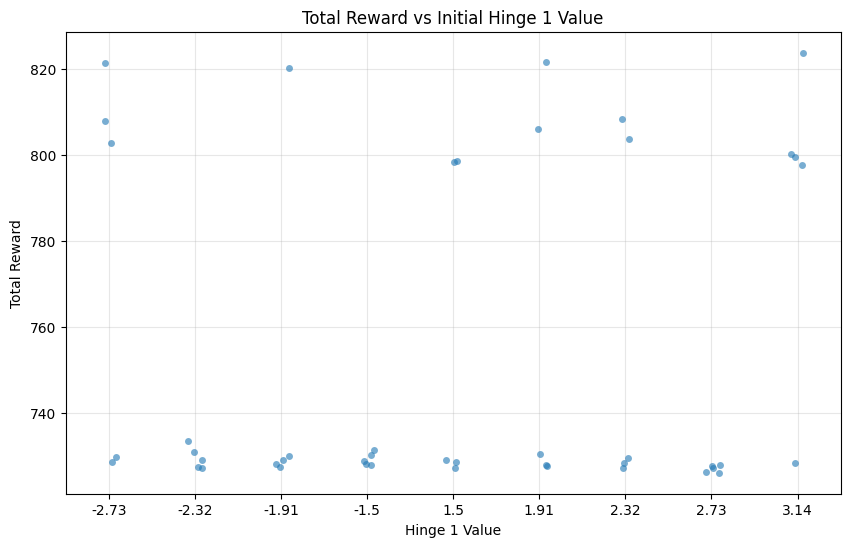

In [12]:
# Strip plot of total reward vs hinge_1_value using seaborn
plt.figure(figsize=(10, 6))
df_plot = pd.DataFrame({
    'hinge_1_value': df_metadata['config_hinge_1_value'],
    'total_reward': df_data['rewards'].apply(lambda x: x.sum())
})
sns.stripplot(data=df_plot, x='hinge_1_value', y='total_reward', alpha=0.6)
plt.xlabel('Hinge 1 Value')
plt.ylabel('Total Reward')
plt.title('Total Reward vs Initial Hinge 1 Value')
plt.grid(True, alpha=0.3)
plt.show()

In [53]:
latents_arr = np.concatenate(df_data['latent_states'], axis=0)
rewards_arr = np.concatenate(df_data['rewards'], axis=0)
actions_arr = np.concatenate(df_data['actions'], axis=0)
observations_arr = np.concatenate(df_data['observations'], axis=0)

print(latents_arr.shape, rewards_arr.shape, actions_arr.shape,
      observations_arr.shape)

print("Removing dimensions with zero entries")
latents_arr = latents_arr[:, (latents_arr != 0).any(axis=0)]
rewards_arr = rewards_arr[:, (rewards_arr != 0).any(axis=0)]
actions_arr = actions_arr[:, (actions_arr != 0).any(axis=0)]
observations_arr = observations_arr[:, (observations_arr != 0).any(axis=0)]
all_arrs = np.concatenate([observations_arr, rewards_arr, actions_arr], axis=1)

print(latents_arr.shape, rewards_arr.shape, actions_arr.shape,
      observations_arr.shape, all_arrs.shape)

(22500, 1376) (22500,) (22500, 6) (22500, 24)
Removing dimensions with zero entries
(22500, 1376) (22500, 1) (22500, 1) (22500, 5) (22500, 7)


## Finding non-aligned spaces 

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA, SparsePCA
from sklearn.preprocessing import StandardScaler


def analyze_latent_to_observation_mapping(Xs,
                                          Ys,
                                          method="pca",
                                          n_components=10):
    """
    observations: [T, D_obs]  -> e.g. DMControl proprioceptive states
    latents: [T, D_latent]    -> TD-MPC2 encoder outputs
    method: 'pca' or 'ica'
    obs_labels: optional list of observation names
    """
    # normalize latents for analysis
    #Z = StandardScaler().fit_transform(latents)
    #O = StandardScaler().fit_transform(observations)

    if method == "pca":
        model = PCA(n_components=n_components)
    elif method == "ica":
        model = FastICA(n_components=n_components, whiten="unit-variance")
    elif method == 'sparse_pca':
        model = SparsePCA(n_components=n_components, alpha=0.1)
    else:
        raise ValueError("method must be 'pca' or 'ica'")

    # Fit decomposition
    F = model.fit_transform(Xs)  # [T, n_components]
    comps = model.components_  # [n_components, D_latent]

    # Correlate each component with each observation variable
    corr_matrix = np.corrcoef(F.T, Ys.T)[:n_components, n_components:]

    # Get explained variance if available
    explained_variance = None
    if hasattr(model, 'explained_variance_ratio_'):
        explained_variance = model.explained_variance_ratio_
        print(f"Explained variance by component: {explained_variance}")
        print(f"Total explained variance: {explained_variance.sum():.3f}")

    return corr_matrix, comps, explained_variance, F


def plot_component_correlations(corr_matrix,
                                obs_labels=None,
                                title="Latent-Observation Map"):
    n_components, D_obs = corr_matrix.shape
    plt.figure(figsize=(12, 4))
    plt.imshow(corr_matrix, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(label='Correlation')
    plt.xlabel("Observation variables")
    plt.ylabel("Latent components")
    plt.title(title)
    if obs_labels:
        plt.xticks(range(D_obs), obs_labels, rotation=90)
    plt.tight_layout()
    plt.show()


In [74]:
all_arrs = np.concatenate([observations_arr, rewards_arr, actions_arr], axis=1)

corr_pca_all, comps_pca_all, exp_var_all, F_all = analyze_latent_to_observation_mapping(
    Xs=latents_arr,
    Ys=all_arrs,
    method="pca",
    n_components=10,
)

comps_pca_eps = []
for eps_idx, row in df_data.iterrows():

    latent_eps = row['latent_states']
    obs_eps = np.array(row['observations'])
    rew_eps = np.array(row['rewards'])
    act_eps = np.array(row['actions'])

    obs_eps = obs_eps[:, (obs_eps != 0).any(axis=0)]
    rew_eps = rew_eps[:, (rew_eps != 0).any(axis=0)]
    act_eps = act_eps[:, (act_eps != 0).any(axis=0)]
    all_eps = np.concatenate([obs_eps, rew_eps, act_eps], axis=1)

    corr_pca, comps_pca, exp_var, F = analyze_latent_to_observation_mapping(
        Xs=latent_eps,
        Ys=all_eps,
        method="pca",
        n_components=10,
    )
    comps_pca_eps.append(comps_pca)

Explained variance by component: [0.21029928 0.1743738  0.14541885 0.1014097  0.06745459 0.05590202
 0.03842698 0.03778153 0.02381249 0.01964507]
Total explained variance: 0.875
Explained variance by component: [0.22425325 0.17467782 0.14291197 0.08271127 0.07024997 0.05813316
 0.04278935 0.0385554  0.02883422 0.02029678]
Total explained variance: 0.883
Explained variance by component: [0.23101373 0.18112703 0.14568052 0.07286931 0.06948747 0.05996683
 0.04245204 0.03650365 0.02869586 0.01989299]
Total explained variance: 0.888
Explained variance by component: [0.23456724 0.17299388 0.14696547 0.08921597 0.07539835 0.06018285
 0.04266236 0.02819222 0.02671884 0.0164538 ]
Total explained variance: 0.893
Explained variance by component: [0.2329417  0.17499903 0.14591019 0.07540879 0.06862131 0.06096435
 0.0422635  0.03706726 0.02614189 0.02067779]
Total explained variance: 0.885
Explained variance by component: [0.23329796 0.1778682  0.14392972 0.07541032 0.06899827 0.05959918
 0.0422249

/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/glfw/__init__.py:914: GLFWError: (65544) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)


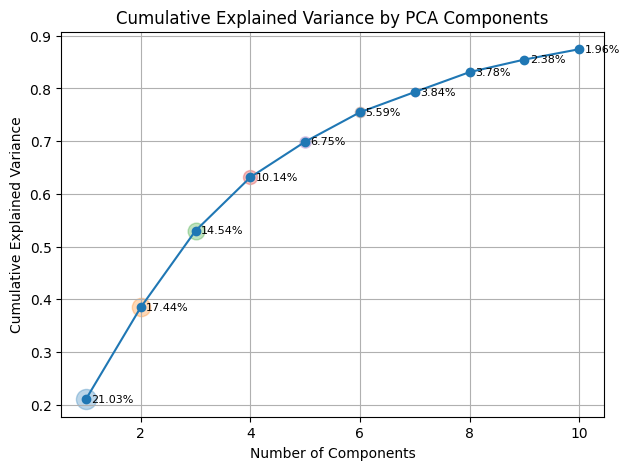

In [81]:
cum_exp_var = np.cumsum(exp_var_all)
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(exp_var_all) + 1), cum_exp_var, marker='o')
for i, var in enumerate(exp_var_all):
    plt.scatter(i + 1, cum_exp_var[i], s=var * 1000, alpha=0.3)
    # Add text annotation for individual component contribution
    plt.text(i + 1.1,
             cum_exp_var[i],
             f'{var:.2%}',
             fontsize=8,
             ha='left',
             va='center')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.show()

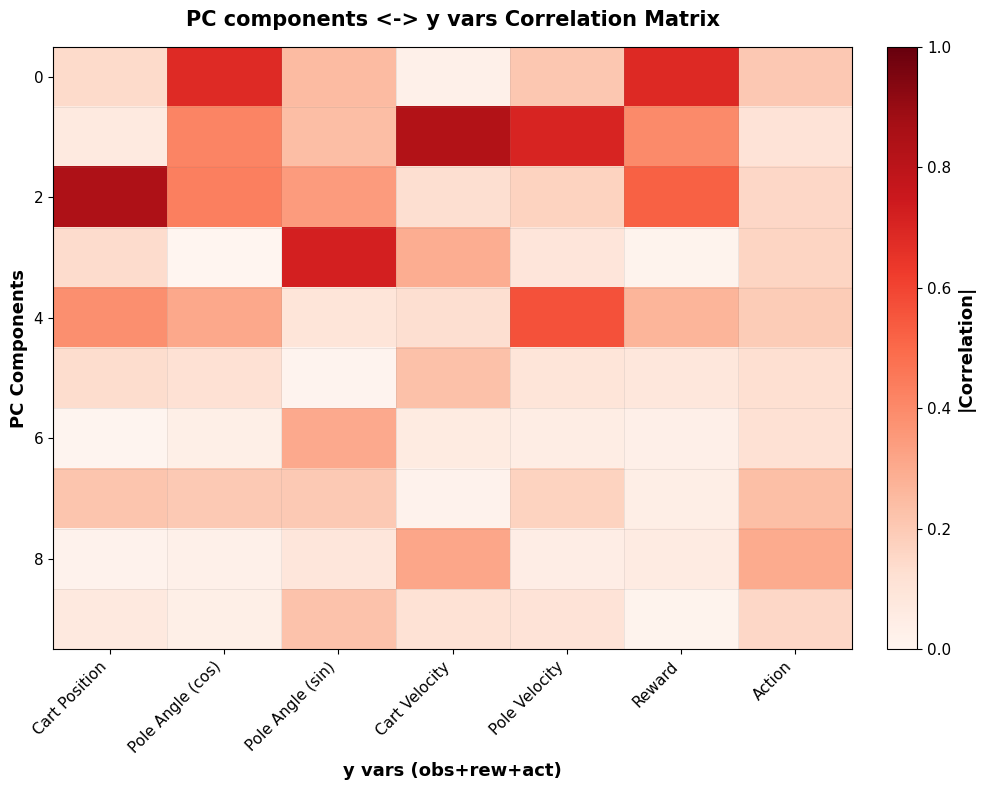

In [83]:
# Define variable order and mapping to better names
variables = [
    'y_obs_cart_pos',
    'y_obs_cospole_ang',
    'y_obs_sinpole_ang',
    'y_obs_cart_vel',
    'y_obs_pole_vel',
    'reward',
    'action',
]

variable_name_mapping = {
    'y_obs_cart_pos': 'Cart Position',
    'y_obs_cospole_ang': 'Pole Angle (cos)',
    'y_obs_sinpole_ang': 'Pole Angle (sin)',
    'y_obs_cart_vel': 'Cart Velocity',
    'y_obs_pole_vel': 'Pole Velocity',
    'reward': 'Reward',
    'action': 'Action',
}

fig, ax = plt.subplots(figsize=(10, 8))

# Create the heatmap with better color normalization
im = ax.imshow(np.abs(corr_pca_all),
               aspect='auto',
               cmap='Reds',
               vmin=0,
               vmax=1,
               interpolation='none')

# Add colorbar with better formatting
cbar = plt.colorbar(im, ax=ax, label='|Correlation|', fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=11)
cbar.set_label('|Correlation|', fontsize=13, weight='bold')

# Set labels with better formatting
ax.set_xlabel('y vars (obs+rew+act)', fontsize=13, weight='bold')
ax.set_ylabel('PC Components', fontsize=13, weight='bold')
ax.set_title('PC components <-> y vars Correlation Matrix',
             fontsize=15,
             weight='bold',
             pad=15)

# Set x-axis tick labels using variable names
ax.set_xticks(np.arange(len(variables)))
ax.set_xticklabels([variable_name_mapping[v] for v in variables],
                   rotation=45,
                   ha='right')

# Improve tick labels
ax.tick_params(axis='both', which='major', labelsize=11)

# Add grid for better readability
ax.set_xticks(np.arange(corr_pca_all.shape[1]) - 0.5, minor=True)
ax.set_yticks(np.arange(corr_pca_all.shape[0]) - 0.5, minor=True)
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.2)

# Remove minor ticks but keep grid
ax.tick_params(which='minor', size=0)

plt.tight_layout()
plt.show()

# Stability analysis

In [76]:
k = comps_pca_all.shape[0]
E = len(comps_pca_eps)
stability = np.zeros(
    (k, E))  # similarity of pooled comp i to best match in episode e

for i in range(k):
    w = comps_pca_all[i]  # (D,)
    for e in range(E):
        pc = comps_pca_eps[e][i]  # (k_e, D)
        # absolute dot products between w and all pcs in episode e
        dots = np.abs(pc @ w)  # (k_e,)
        best = dots.max()
        stability[i, e] = best

# summary stats per pooled component
mean_sim = stability.mean(axis=1)  # (k,)
std_sim = stability.std(axis=1)
median_sim = np.median(stability, axis=1)
frac_above = (stability >= 0.7).mean(
    axis=1)  # fraction of episodes where best match >= 0.7

# Example: print top stable components
for i in np.argsort(-mean_sim)[:10]:
    print(
        f"comp {i}: mean={mean_sim[i]:.3f}, std={std_sim[i]:.3f}, frac_above0.7={frac_above[i]:.2f}"
    )


comp 0: mean=0.850, std=0.257, frac_above0.7=0.91
comp 1: mean=0.830, std=0.192, frac_above0.7=0.84
comp 5: mean=0.818, std=0.201, frac_above0.7=0.78
comp 4: mean=0.799, std=0.271, frac_above0.7=0.84
comp 2: mean=0.773, std=0.176, frac_above0.7=0.78
comp 9: mean=0.741, std=0.339, frac_above0.7=0.69
comp 8: mean=0.695, std=0.350, frac_above0.7=0.69
comp 3: mean=0.675, std=0.226, frac_above0.7=0.67
comp 6: mean=0.252, std=0.303, frac_above0.7=0.22
comp 7: mean=0.247, std=0.201, frac_above0.7=0.09


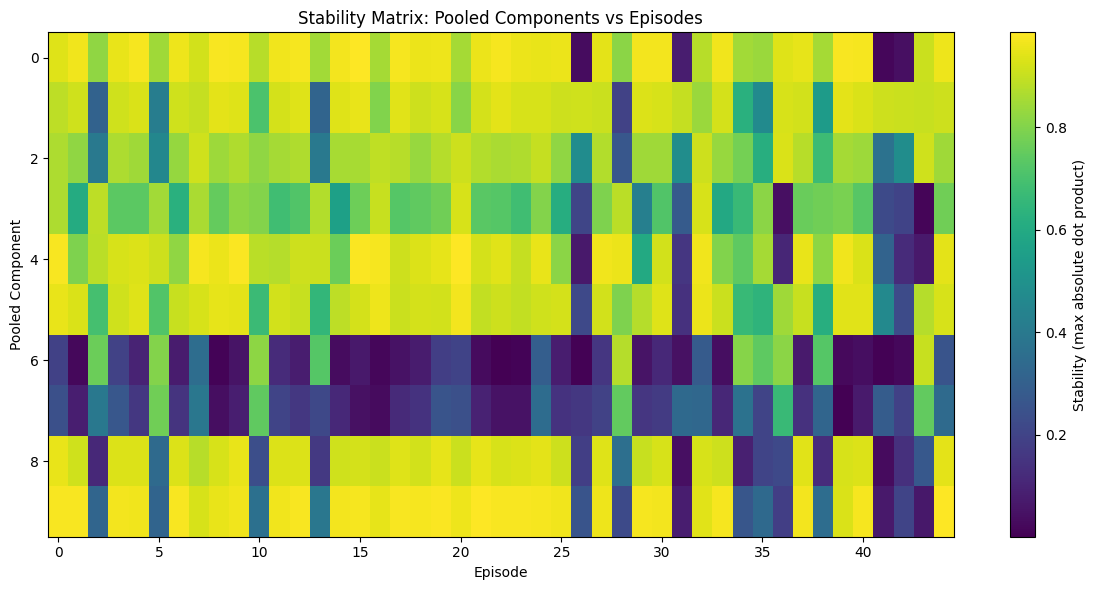

In [77]:
plt.figure(figsize=(12, 6))
plt.imshow(stability, aspect='auto', cmap='viridis')
plt.colorbar(label='Stability (max absolute dot product)')
plt.xlabel('Episode')
plt.ylabel('Pooled Component')
plt.title('Stability Matrix: Pooled Components vs Episodes')
plt.tight_layout()
plt.show()

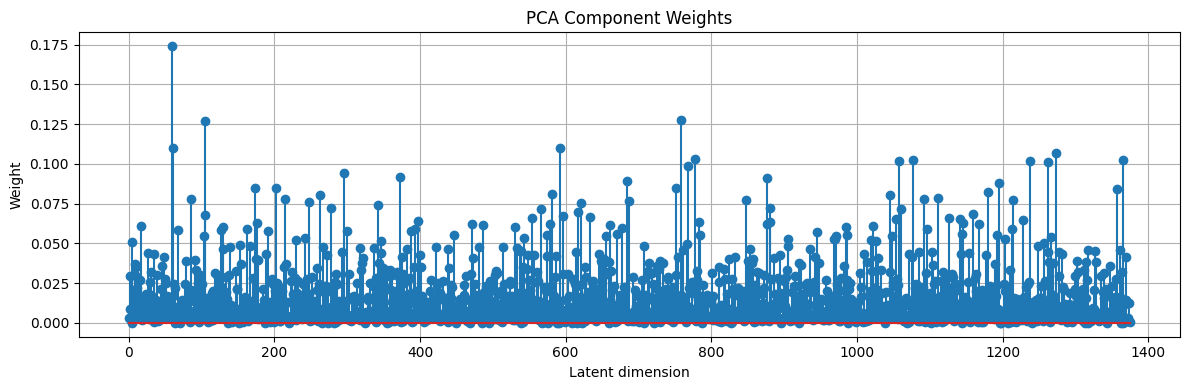

In [78]:
idx = 0
w = comps_pca_all[idx]
plt.figure(figsize=(12, 4))
plt.stem(abs(w))
plt.xlabel('Latent dimension')
plt.ylabel('Weight')
plt.title('PCA Component Weights')
plt.grid(True)
plt.tight_layout()
plt.show()

In [79]:
np.savez('selected_dirs_pca_mt30-317.npz', comps_pca_all=comps_pca_all)

## sparsitfy directions

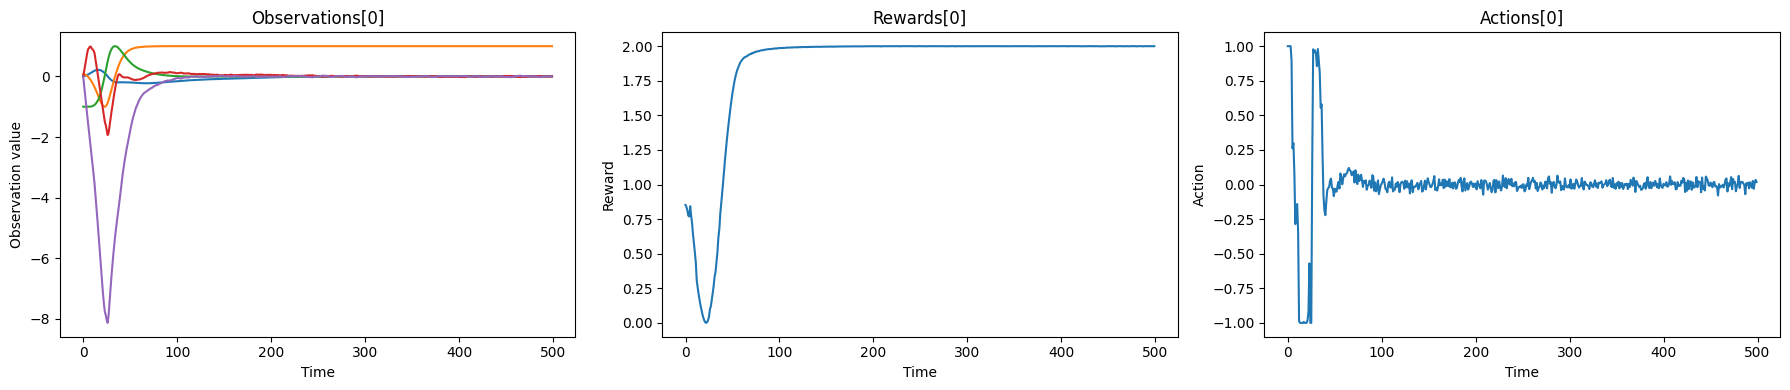

In [47]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4))

eps_idx = 0
axs[0].plot(observations[eps_idx])
axs[0].set_title('Observations[0]')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Observation value')

axs[1].plot(rewards[eps_idx])
axs[1].set_title('Rewards[0]')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Reward')

axs[2].plot(actions[eps_idx])
axs[2].set_title('Actions[0]')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Action')

plt.tight_layout()
plt.show()

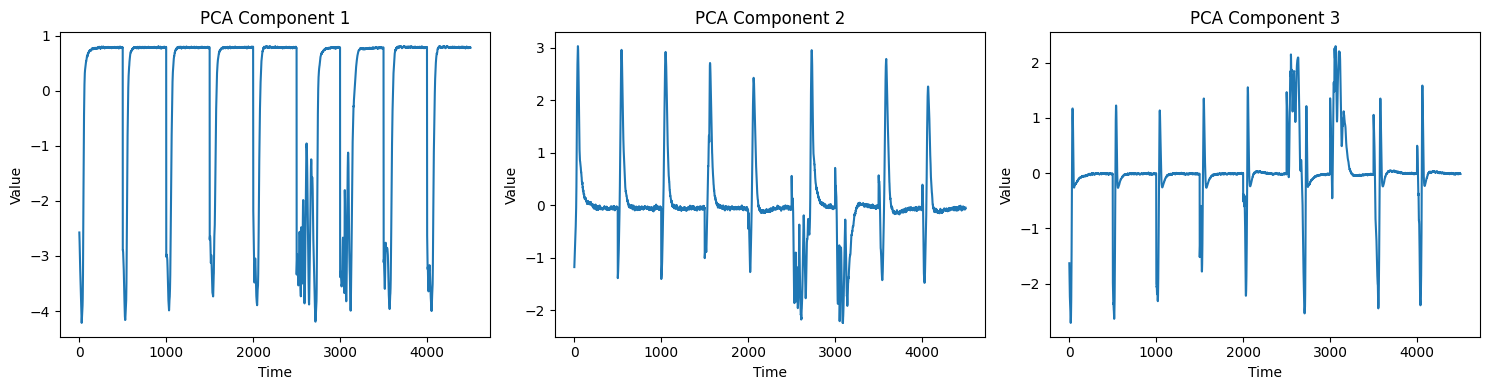

In [118]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    axs[i].plot(F_all[:, i])
    axs[i].set_title(f'PCA Component {i+1}')
    axs[i].set_xlabel('Time')
    axs[i].set_ylabel('Value')

plt.tight_layout()
plt.show()


In [82]:
def denoise_pca_direction_np(v, eps_frac=1e-3):
    """
    v: original PCA component (1D numpy array)
    eps_frac: threshold fraction of max(abs(v))
    returns: v_hat (unit vector), cosine_sim, n_nonzero
    """
    v = v.astype(float)
    maxabs = np.max(np.abs(v))
    thr = eps_frac * maxabs
    v_thr = v.copy()
    v_thr[np.abs(v_thr) < thr] = 0.0
    norm = np.linalg.norm(v_thr)
    if norm == 0:
        raise ValueError("threshold too large; all entries zeroed")
    v_hat = v_thr / norm
    cosine = float(np.dot(v_hat, v) / (np.linalg.norm(v) + 1e-12))
    return v_hat, cosine, int((np.abs(v_hat) > 0).sum())

In [146]:
eps_fracs = [
    0, 0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6,
    0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0
]
results = {}
for idx, comp in enumerate(comps_pca_all):
    results[idx] = {}
    for eps_frac in eps_fracs:
        vhat, cosine, n_nonzero = denoise_pca_direction_np(comp,
                                                           eps_frac=eps_frac)
        results[idx][eps_frac] = {
            "comp_sparse": vhat,
            "cosine": cosine,
            "n_nonzero": n_nonzero,
        }
        print(
            f"component: {idx}, eps_frac: {eps_frac}, cosine: {cosine}, n_nonzero: {n_nonzero}"
        )

component: 0, eps_frac: 0, cosine: 0.9999999999989999, n_nonzero: 512
component: 0, eps_frac: 0.01, cosine: 0.9999825719588856, n_nonzero: 490
component: 0, eps_frac: 0.05, cosine: 0.9979355306336901, n_nonzero: 368
component: 0, eps_frac: 0.1, cosine: 0.9854555746493752, n_nonzero: 244
component: 0, eps_frac: 0.15, cosine: 0.9592987839168002, n_nonzero: 155
component: 0, eps_frac: 0.2, cosine: 0.931089778896585, n_nonzero: 109
component: 0, eps_frac: 0.25, cosine: 0.9067390290004379, n_nonzero: 86
component: 0, eps_frac: 0.3, cosine: 0.8781776933752498, n_nonzero: 68
component: 0, eps_frac: 0.35, cosine: 0.844934327033353, n_nonzero: 53
component: 0, eps_frac: 0.4, cosine: 0.8102438408613983, n_nonzero: 42
component: 0, eps_frac: 0.45, cosine: 0.7808061909348849, n_nonzero: 35
component: 0, eps_frac: 0.5, cosine: 0.7471136884868426, n_nonzero: 29
component: 0, eps_frac: 0.55, cosine: 0.7276864260481666, n_nonzero: 26
component: 0, eps_frac: 0.6, cosine: 0.6824384811877512, n_nonzero: 

/scratch/slurm_tmpdir/job_1585480/ipykernel_1987438/4087605059.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('Reds', num_components)


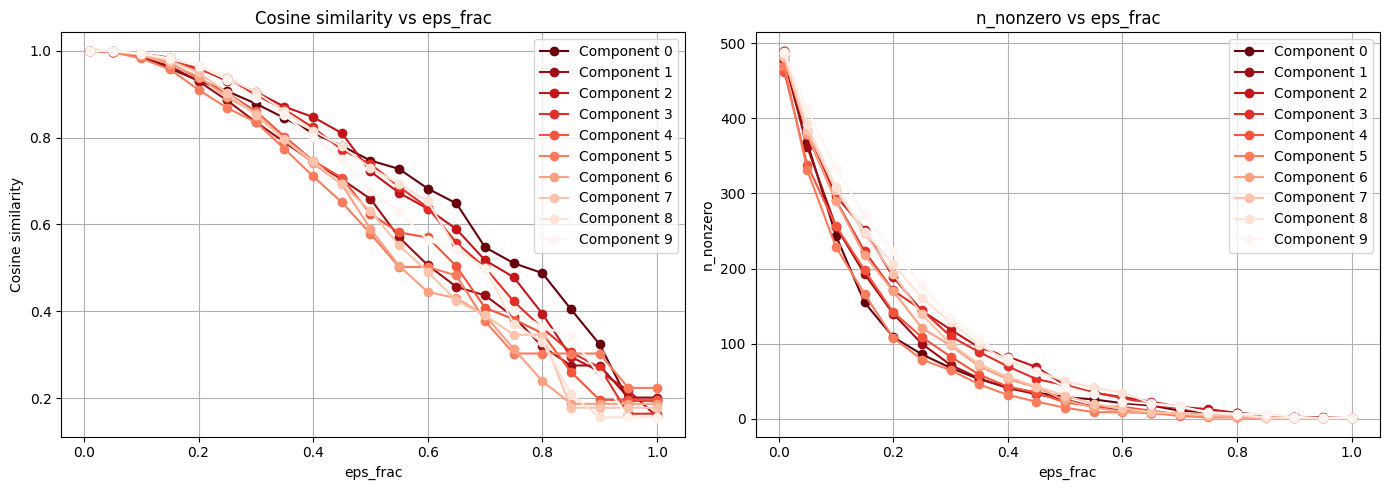

In [139]:
import matplotlib as mpl

# Set up a red colormap from bright to dark (brightest red to darkest red)
num_components = len(results.keys())
cmap = mpl.cm.get_cmap('Reds', num_components)
# To make the brightest red correspond to idx=0, reverse the colors
colors = [
    cmap(1.0 - (i / max(1, num_components - 1))) for i in range(num_components)
]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot cosine similarity and n_nonzero with red color mapping
for i, idx in enumerate(results.keys()):
    epsilons = []
    cosines = []
    n_nonzero = []
    for eps_frac in eps_fracs:
        epsilons.append(eps_frac)
        cosines.append(results[idx][eps_frac]["cosine"])
        n_nonzero.append(results[idx][eps_frac]["n_nonzero"])
    axs[0].plot(epsilons,
                cosines,
                marker='o',
                label=f'Component {idx}',
                color=colors[i])
    axs[1].plot(epsilons,
                n_nonzero,
                marker='o',
                label=f'Component {idx}',
                color=colors[i])

axs[0].set_xlabel('eps_frac')
axs[0].set_ylabel('Cosine similarity')
axs[0].set_title('Cosine similarity vs eps_frac')

axs[1].set_xlabel('eps_frac')
axs[1].set_ylabel('n_nonzero')
axs[1].set_title('n_nonzero vs eps_frac')

axs[0].legend()
axs[0].grid(True)
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [155]:
import pickle
with open("selected_dirs_pca_sparse_all.pkl", "wb") as f:
    pickle.dump(results, f)

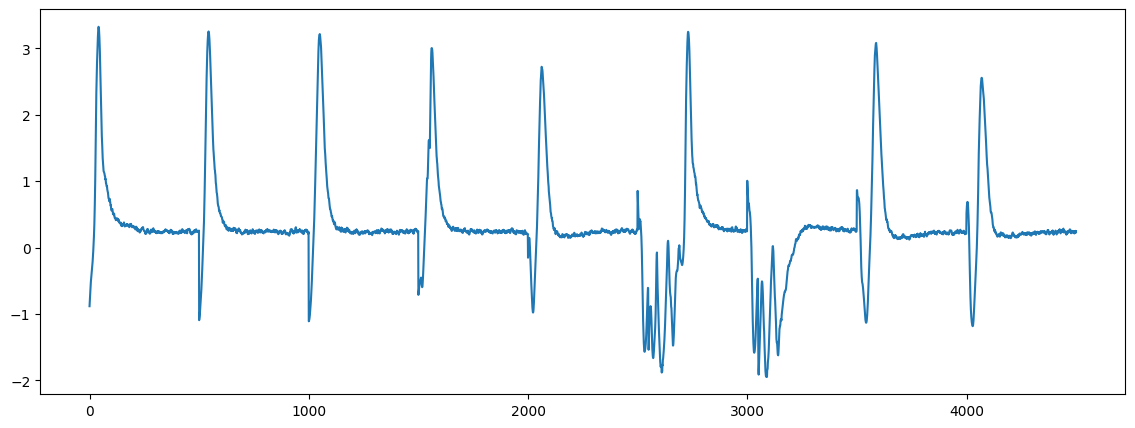

In [142]:
pc_components = (np.dot(comps_pca_all, latents_arr.T))
plt.figure(figsize=(14, 5))
plt.plot(pc_components[1])
plt.show()

/scratch/slurm_tmpdir/job_1585480/ipykernel_1987438/1264354044.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('Reds', num_eps)


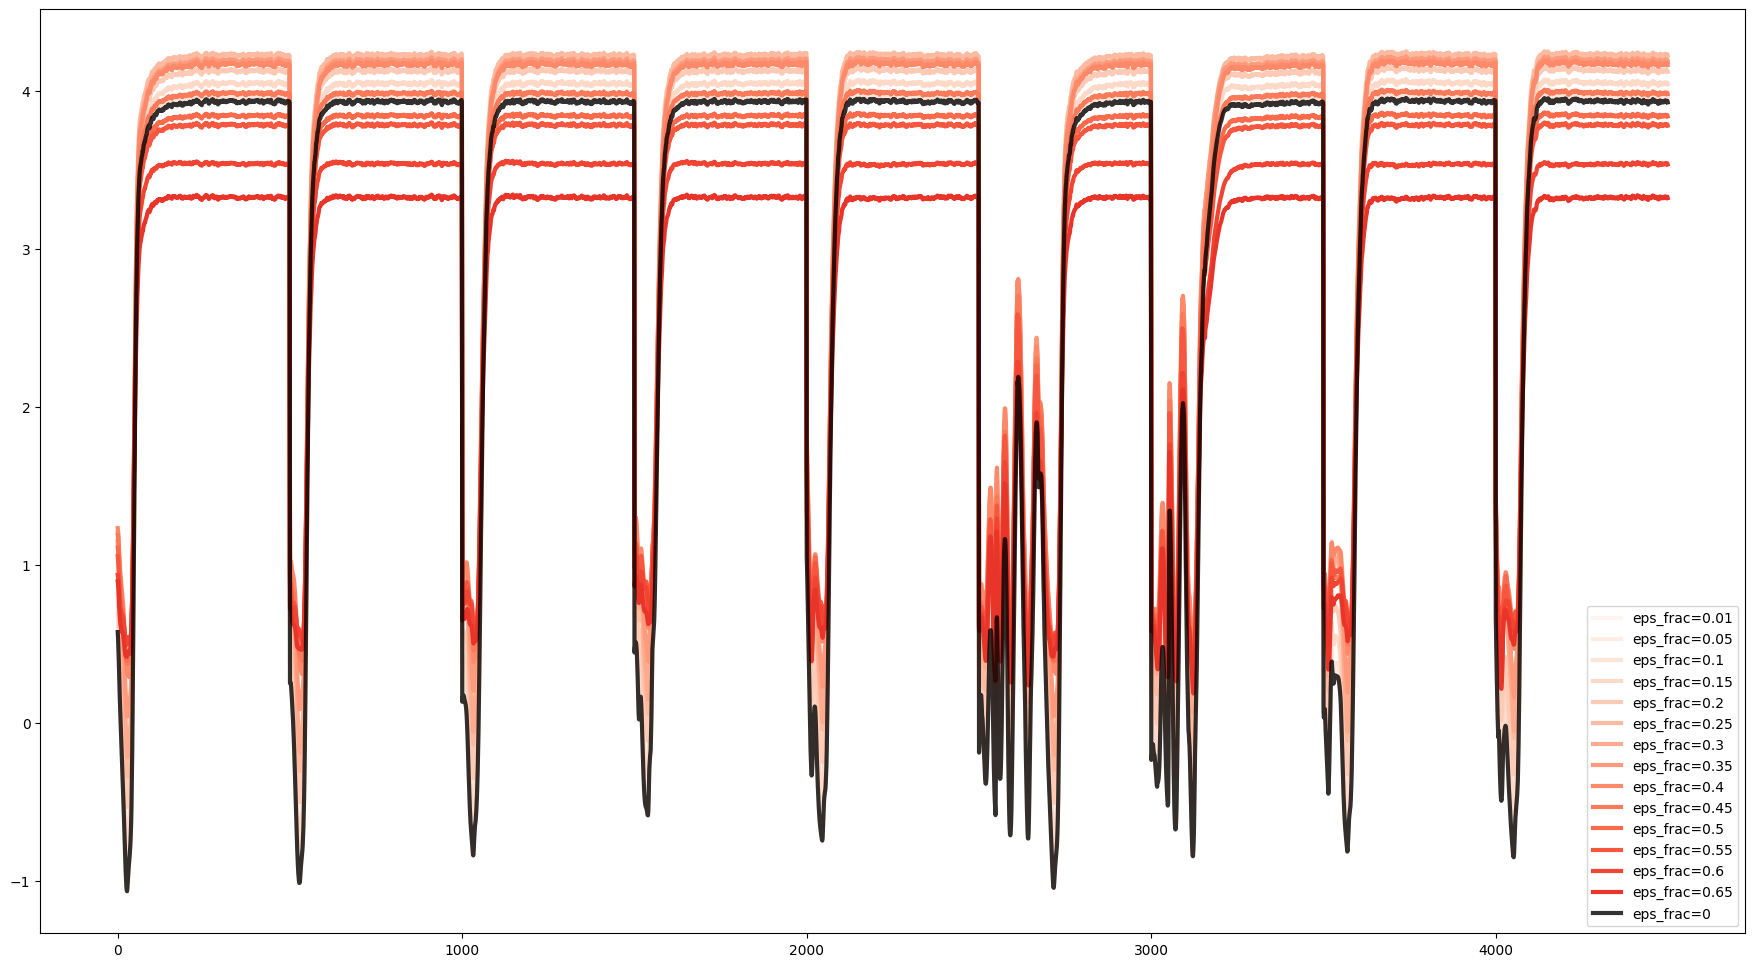

In [154]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

rr = results[0]

eps_fracs = sorted(rr.keys())
num_eps = len(eps_fracs) - 1

# Reds colormap from light to dark (low index = light, high = dark)
cmap = mpl.cm.get_cmap('Reds', num_eps)
colors = [cmap(i) for i in range(num_eps)]

plt.figure(figsize=(22, 12))  # wider figure
for idx, eps_frac in enumerate(eps_fracs[1:15]):
    plt.plot(latents_arr @ rr[eps_frac]["comp_sparse"].T,
             color=colors[idx],
             alpha=1.0,
             linewidth=3,
             label=f"eps_frac={eps_frac}")

plt.plot(latents_arr @ rr[0]["comp_sparse"].T,
         color='black',
         alpha=0.8,
         linewidth=3,
         label=f"eps_frac=0")

plt.legend()
plt.show()


## project latents into this one direction

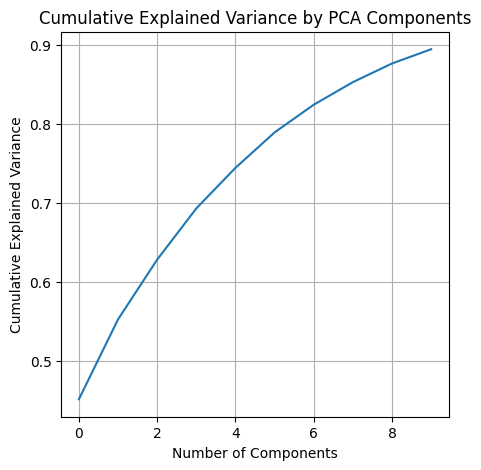

In [215]:
cum_exp_var = np.cumsum(exp_var_all)
plt.figure(figsize=(5, 5))
plt.plot(cum_exp_var)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.show()

In [216]:
import torch


def reconstruct_latents(latents,
                        components,
                        add_simnorm=True,
                        renormalize=False,
                        simnorm_dim=8):
    """Keep only first k PCA components, zero out all others"""
    # latents shape: (batch, latent_dim)
    # components shape: (k, latent_dim)

    # Project onto first k components and reconstruct
    coeffs = latents @ components.T  # (batch, k)
    latents_reconstructed = coeffs @ components  # (batch, latent_dim)

    if add_simnorm:
        # Re-apply SimNorm to maintain the model's expected distribution
        # SimNorm groups dimensions and applies softmax within each group
        shp = latents_reconstructed.shape
        latents_reconstructed = latents_reconstructed.view(
            *shp[:-1], -1, simnorm_dim)
        latents_reconstructed = torch.nn.functional.softmax(
            latents_reconstructed, dim=-1)
        latents_reconstructed = latents_reconstructed.view(*shp)

    if renormalize:
        # Simple min-max normalization to [0, 1] per sample
        min_vals = latents_reconstructed.min(dim=-1, keepdim=True)[0]
        max_vals = latents_reconstructed.max(dim=-1, keepdim=True)[0]
        latents_reconstructed = (latents_reconstructed -
                                 min_vals) / (max_vals - min_vals + 1e-8)
    return latents_reconstructed

In [221]:
reconstructed_latents = reconstruct_latents(torch.from_numpy(latents_arr),
                                            add_simnorm=False,
                                            renormalize=True,
                                            components=comps_pca_all[:1])

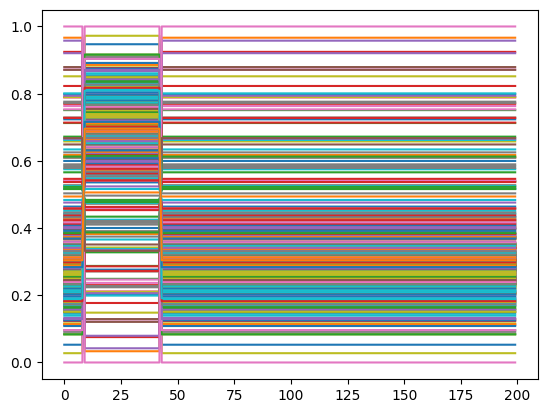

In [222]:
plt.plot(reconstructed_latents[:200])
plt.show()

In [266]:
corr_pca_all, comps_pca_all, exp_var_all, F_all = analyze_latent_to_observation_mapping(
    Xs=latents_arr,
    Ys=all_arrs,
    method="pca",
    n_components=100,
)

reconstructed_latents = reconstruct_latents(torch.from_numpy(latents_arr),
                                            add_simnorm=True,
                                            renormalize=False,
                                            components=comps_pca_all[:])
reconstructed_latents = reconstructed_latents.numpy()

Explained variance by component: [4.51449364e-01 1.00987010e-01 7.56025910e-02 6.47898093e-02
 5.13321459e-02 4.48070876e-02 3.50235030e-02 2.85565630e-02
 2.36014109e-02 1.80432592e-02 1.22563764e-02 1.00603430e-02
 8.78421497e-03 7.31927948e-03 6.53641718e-03 5.90189453e-03
 5.16313734e-03 4.42477781e-03 3.79582145e-03 3.57178762e-03
 3.28681758e-03 2.96219694e-03 2.92549445e-03 2.20293039e-03
 2.09251395e-03 1.89772423e-03 1.84961385e-03 1.65873207e-03
 1.50558806e-03 1.22605520e-03 1.10246462e-03 1.02032628e-03
 9.32811992e-04 8.79718922e-04 8.39869375e-04 6.48166460e-04
 6.26832014e-04 6.02824730e-04 5.77451603e-04 5.29142271e-04
 4.90579114e-04 4.78354399e-04 4.26624407e-04 3.83182429e-04
 3.49373615e-04 3.42973595e-04 3.34135751e-04 3.11915559e-04
 2.85137969e-04 2.77917716e-04 2.38751847e-04 2.26204225e-04
 2.14766347e-04 1.96743218e-04 1.87598882e-04 1.80072093e-04
 1.68993472e-04 1.68187107e-04 1.61479926e-04 1.45099242e-04
 1.42703604e-04 1.31674024e-04 1.21598205e-04 1.1201

In [267]:
print("Reconstruction error:", np.mean(
    (latents_arr - reconstructed_latents)**2))

Reconstruction error: 0.026538609


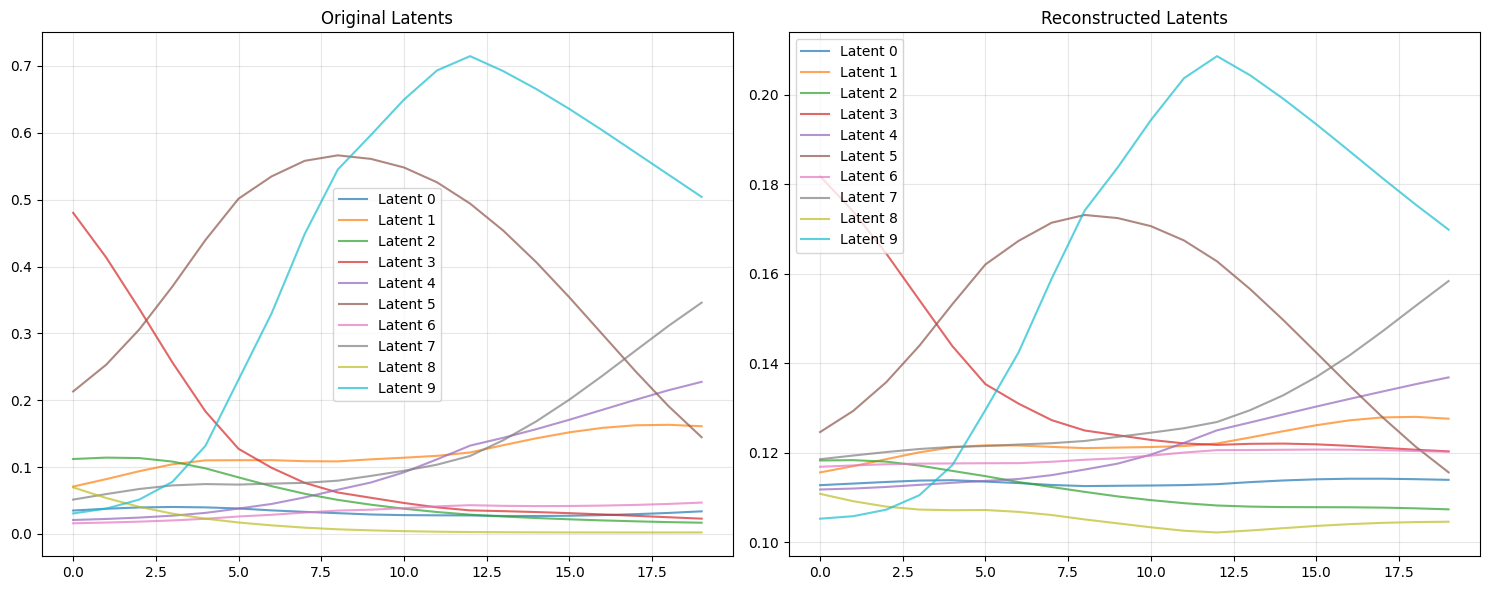

In [268]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot original latents
n_points_to_plot = 20
for i in range(10):
    ax1.plot(latents_arr[:n_points_to_plot, i], label=f'Latent {i}', alpha=0.7)
ax1.set_title('Original Latents')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot reconstructed latents
for i in range(10):
    ax2.plot(reconstructed_latents[:n_points_to_plot, i],
             label=f'Latent {i}',
             alpha=0.7)
ax2.set_title('Reconstructed Latents')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [229]:
import numpy as np
from sklearn.decomposition import PCA


def pca_reconstruct(X, n_components):
    """
    Perform PCA on X with n_components and reconstruct the data.
    
    Parameters
    ----------
    X : np.ndarray
        Input data of shape (N, d).
    n_components : int
        Number of principal components to retain.
    
    Returns
    -------
    X_reconstructed : np.ndarray
        Reconstructed version of X, same shape as X.
    pca : PCA object
        The fitted PCA model.
    """
    # Fit PCA
    pca = PCA(n_components=n_components)
    Z = pca.fit_transform(X)  # (N, n_components)

    # Reconstruct data
    X_reconstructed = pca.inverse_transform(Z)  # (N, d)

    return X_reconstructed, pca


In [234]:
X = np.random.randn(1000, 200)
X_rec, pca = pca_reconstruct(X, n_components=200)

print("Reconstruction error:", np.mean((X - X_rec)**2))

Reconstruction error: 8.029760337364685e-30
